In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openquake.commonlib.datastore import read


In [2]:
!oq engine --lrc

job_id |     status |          start_time |         description
     1 |   complete | 2024-11-03 12:06:15.308445 | Scenario Risk Demo (Catania Tsunami) using hysea simulation no aggregation
     2 |   complete | 2024-11-03 12:06:35.087976 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 892 no aggregation
     3 |   complete | 2024-11-03 12:06:54.806854 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 1658 no aggregation
     4 |   complete | 2024-11-03 12:07:16.469549 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 3454 no aggregation
     5 |   complete | 2024-11-03 12:12:18.075475 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 7071 no aggregation
     6 |   complete | 2024-11-03 13:17:53.362380 | Scenario Risk Demo (Catania Tsunami) using hysea simulation with foglio aggregation
     7 |   complete | 2024-11-03 13:19:15.386250 | Scenario Risk Demo (C

In [3]:
dstore = read(11)
list(dstore)


['agg_keys',
 'agg_values',
 'assetcol',
 'avg_losses-rlzs',
 'crm',
 'discarded',
 'events',
 'exposure',
 'full_lt',
 'gmf_data',
 'oqparam',
 'performance_data',
 'risk_by_event',
 'rupgeoms',
 'ruptures',
 'sitecol',
 'task_info',
 'task_sent',
 'taxmap',
 'weights']

In [4]:
dstore.read_df('risk_by_event').head()
# dstore.close()

,event_id,agg_id,loss_id,variance,loss
0,53433,9414,3,0.0,4.245314e+06
1,53434,9414,3,0.0,8.007347e+05
2,53435,9414,3,0.0,4.158568e+02
3,53436,9414,3,0.0,7.612706e+06
4,53437,9414,3,0.0,2.159918e+06


In [5]:
file = '/home/naveen.raguramalinga/oqdata/calc_11.hdf5'

with h5py.File(file, 'r') as f:
    agg_keys = f['agg_keys'][:]
    f.close()

# remove b in string values in the np array agg_keys,ex b'19089001000000292200' to 19089001000000292200
agg_keys = np.array([x.decode('utf-8') for x in agg_keys])

# convert the np array to a pandas dataframe
agg_keys = pd.DataFrame(agg_keys, columns=['IDAG'])
agg_keys['agg_id'] = agg_keys.index
num_keys = len(agg_keys)

# #save IDAG and agg_id key to a csv file
# agg_keys.to_csv('0_agg_keys.csv', index=False)

In [9]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv', header=0)
event_info['event_id'] = event_info.index
exposure_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/building_exposure.csv', header=0)[['IDAG', 'Elevation', 'Construction', 'FloorType', 'Building_Class']]

run_name = ['true','892','1658','3454','7071']
for i, job_id in enumerate([11, 12, 13 ,14, 15]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')

    # Remove rows with agg_id with total from agg_keys
    data_event = data_event[data_event['agg_id'] != num_keys]

    # Join the data with the agg_keys
    data_event = data_event.join(agg_keys.set_index('agg_id'), on='agg_id')
    data_event = data_event.sort_values(by='event_id')

    # Join the data from the exposure_info using IDAG as the key
    data_event = data_event.join(exposure_info.set_index('IDAG'), on='IDAG')

    # Filter based on exposure category - FloorType(LR, MR, HR)
    data_event_HR = data_event[data_event['FloorType'] == 'HR']
    data_event_MR = data_event[data_event['FloorType'] == 'MR']
    data_event_LR = data_event[data_event['FloorType'] == 'LR']

    # Aggregate the data based on event_id
    event_loss_HR = data_event_HR.groupby('event_id')['loss'].sum()
    event_loss_MR = data_event_MR.groupby('event_id')['loss'].sum()
    event_loss_LR = data_event_LR.groupby('event_id')['loss'].sum()

    # Remove events index with less than 50 loss value
    event_loss_HR = event_loss_HR[event_loss_HR > 50]
    event_loss_MR = event_loss_MR[event_loss_MR > 50]
    event_loss_LR = event_loss_LR[event_loss_LR > 50]

    # Number of events
    print('Number of events:', len(event_loss_HR), len(event_loss_MR), len(event_loss_LR))

    # Append event_loss to event_info
    event_info = event_info.join(event_loss_HR, on='event_id', rsuffix=f'_HR_{run_name[i]}')
    event_info = event_info.join(event_loss_MR, on='event_id', rsuffix=f'_MR_{run_name[i]}')
    event_info = event_info.join(event_loss_LR, on='event_id', rsuffix=f'_LR_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_HR_true'}, inplace=True)
# Save the updated data to a csv file
event_info.to_csv('3_event_info_Floor_loss.csv', index=False)


Job 11 for true
Number of events: 9 30056 31438
Job 12 for 892
Number of events: 1 30101 30584
Job 13 for 1658
Number of events: 1 32689 35229
Job 14 for 3454
Number of events: 5 29321 31334
Job 15 for 7071
Number of events: 1 29455 30714


In [ ]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index
exposure_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/building_exposure.csv',header=0)[['IDAG','Elevation','Construction','FloorType','Building_Class']]

run_name = ['true','892','1658','3454','7071']
for i, job_id in enumerate([11, 12, 13 ,14, 15]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')

    #remove rows with agg_id with total from agg_keys
    # direct_event_loss = data_event[data_event['agg_id'] == num_keys]
    data_event = data_event[data_event['agg_id'] != num_keys]

    #Join the data with the agg_keys
    data_event = data_event.join(agg_keys.set_index('agg_id'), on='agg_id')
    data_event = data_event.sort_values(by='event_id')

    #Join the data from the exposure_info using IDAG as the key
    data_event = data_event.join(exposure_info.set_index('IDAG'), on='IDAG')
    
    #filter based on exposure category - FloorType(LR,MR,HR)
    data_event_LE = data_event[data_event['Elevation'] <= 1.5]
    data_event_ME = data_event[(data_event['Elevation']  > 1.5) & (data_event['Elevation'] <= 3)]
    data_event_HE = data_event[data_event['Elevation']  > 3]

    #aggregate the data based on event_id
    event_loss_HE = data_event_HE.groupby('event_id')['loss'].sum()
    event_loss_ME = data_event_ME.groupby('event_id')['loss'].sum()
    event_loss_LE = data_event_LE.groupby('event_id')['loss'].sum()

    #remove events index with less than 50 loss value
    event_loss_HE = event_loss_HE[event_loss_HE > 50]
    event_loss_ME = event_loss_ME[event_loss_ME > 50]
    event_loss_LE = event_loss_LE[event_loss_LE > 50]

    #number of events
    print('Number of events:', len(event_loss_HE), len(event_loss_ME), len(event_loss_LE))

    #append event_loss to event_info
    event_info = event_info.join(event_loss_HE, on='event_id', rsuffix=f'_HE_{run_name[i]}')
    event_info = event_info.join(event_loss_ME, on='event_id', rsuffix=f'_ME_{run_name[i]}')
    event_info = event_info.join(event_loss_LE, on='event_id', rsuffix=f'_LE_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_HE_true'}, inplace=True)

# Save the updated data to a csv file
event_info.to_csv('3_event_info_Elevation_loss.csv', index=False)


Job 11 for true
Number of events: 18778 28563 32102
Job 12 for 892
Number of events: 17556 27332 31154
Job 13 for 1658
Number of events: 19390 29991 35234
Job 14 for 3454
Number of events: 19074 28726 31336
Job 15 for 7071
Number of events: 18827 28402 30857


Vulnerability or Building Class

In [13]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index
exposure_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/loss/building_exposure.csv',header=0)[['IDAG','Elevation','Construction','FloorType','Building_Class']]

run_name = ['true','892','1658','3454','7071']
for i, job_id in enumerate([11, 12, 13 ,14, 15]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')

    #remove rows with agg_id with total from agg_keys
    # direct_event_loss = data_event[data_event['agg_id'] == num_keys]
    data_event = data_event[data_event['agg_id'] != num_keys]

    #Join the data with the agg_keys
    data_event = data_event.join(agg_keys.set_index('agg_id'), on='agg_id')
    data_event = data_event.sort_values(by='event_id')

    #Join the data from the exposure_info using IDAG as the key
    data_event = data_event.join(exposure_info.set_index('IDAG'), on='IDAG')
    
    #filter based on exposure category - FloorType(LR,MR,HR)
    data_event_M_LR = data_event[data_event['Building_Class'] == 'M_LR']
    data_event_M_MR = data_event[data_event['Building_Class'] == 'M_MR']
    data_event_RC_LR = data_event[data_event['Building_Class'] == 'RC_LR']
    data_event_RC_MR = data_event[data_event['Building_Class'] == 'RC_MR']
    data_event_RC_HR = data_event[data_event['Building_Class'] == 'RC_HR']

    #aggregate the data based on event_id
    event_loss_M_LR = data_event_M_LR.groupby('event_id')['loss'].sum()
    event_loss_M_MR = data_event_M_MR.groupby('event_id')['loss'].sum()
    event_loss_RC_LR = data_event_RC_LR.groupby('event_id')['loss'].sum()
    event_loss_RC_MR = data_event_RC_MR.groupby('event_id')['loss'].sum()
    event_loss_RC_HR = data_event_RC_HR.groupby('event_id')['loss'].sum()
   

    #remove events index with less than 50 loss value
    event_loss_M_LR = event_loss_M_LR[event_loss_M_LR > 50]
    event_loss_M_MR = event_loss_M_MR[event_loss_M_MR > 50]
    event_loss_RC_LR = event_loss_RC_LR[event_loss_RC_LR > 50]
    event_loss_RC_MR = event_loss_RC_MR[event_loss_RC_MR > 50]
    event_loss_RC_HR = event_loss_RC_HR[event_loss_RC_HR > 50]

    #number of events
    print('Number of M events:', len(event_loss_M_LR), len(event_loss_M_MR))
    print('Number of RC events:', len(event_loss_RC_LR), len(event_loss_RC_MR), len(event_loss_RC_HR))

    #append event_loss to event_info
    event_info = event_info.join(event_loss_M_LR, on='event_id', rsuffix=f'_M_LR_{run_name[i]}')
    event_info = event_info.join(event_loss_M_MR, on='event_id', rsuffix=f'_M_MR_{run_name[i]}')
    event_info = event_info.join(event_loss_RC_LR, on='event_id', rsuffix=f'_RC_LR_{run_name[i]}')
    event_info = event_info.join(event_loss_RC_MR, on='event_id', rsuffix=f'_RC_MR_{run_name[i]}')
    event_info = event_info.join(event_loss_RC_HR, on='event_id', rsuffix=f'_RC_HR_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_M_LR_true'}, inplace=True)

# Save the updated data to a csv file
event_info.to_csv('3_event_info_Class_loss.csv', index=False)


Job 11 for true
Number of M events: 28335 25904
Number of RC events: 31249 29450 9
Job 12 for 892
Number of M events: 27708 23413
Number of RC events: 30516 29796 1
Job 13 for 1658
Number of M events: 27552 25461
Number of RC events: 35056 31931 1
Job 14 for 3454
Number of M events: 29215 25152
Number of RC events: 31203 28780 5
Job 15 for 7071
Number of M events: 28534 24758
Number of RC events: 30659 28975 1


In [ ]:
#read event_info_agg_loss.csv
event_info = pd.read_csv('3_event_info_agg_loss.csv',header=0)

In [14]:
def get_loss_pml(loss,rate,threshold,PoE,total_value = 28491684200):
    
    #filter events based on threshold of 500
    # print('Number of events before filtering:', len(loss))
    rate = rate[loss>threshold]
    loss = loss[loss>threshold]
    # print('Number of events after filtering:', len(loss))

    #reset index
    rate = rate.reset_index(drop=True)
    loss = loss.reset_index(drop=True)

    #sort descending
    idx = np.argsort(loss)[::-1]
    sorted_loss = loss[idx]
    sorted_rate = rate[idx]  
    
    #Event loss table
    ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
    ELT['weighted_loss'] = sorted_loss*sorted_rate
    ELT['cumulative_probability'] = ELT['rate'].cumsum()

    AAL = np.sum(ELT['weighted_loss'])
    # print('AAL:',AAL,'\n')

    PML = np.zeros(len(PoE))
    PML_ratio = np.zeros(len(PoE))
    #find the event loss for each RP
    for i,probability_level in enumerate(PoE):
        # print(probability_level,len(ELT['loss'][ELT['cumulative_probability']>probability_level]))
        PML[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()
        if PML[i] == np.nan:
            PML_ratio[i] = 0
        else:
            PML_ratio[i] = PML[i]/total_value
    return PML,PML_ratio,ELT,AAL

Number of events before filtering: 53550
Number of events after filtering: 31045
AAL: 20169.989239660295 

Number of events before filtering: 53550
Number of events after filtering: 29413
AAL: 14583.916800502835 

Number of events before filtering: 53550
Number of events after filtering: 32548
AAL: 18543.52825523648 

Number of events before filtering: 53550
Number of events after filtering: 30199
AAL: 15929.3439419328 

Number of events before filtering: 53550
Number of events after filtering: 30023
AAL: 16446.225653797777 



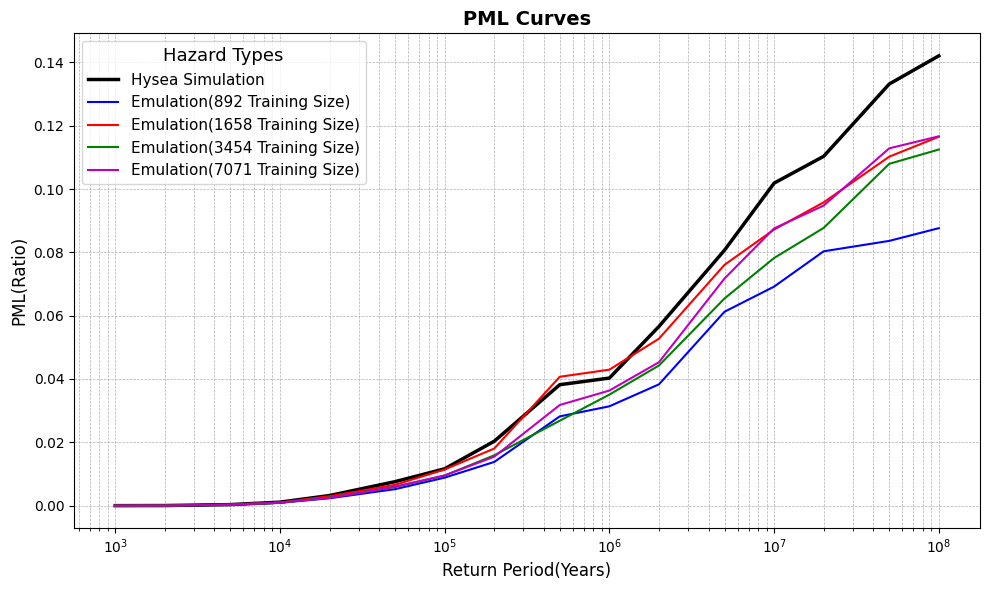

In [5]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10, 20, 50,
      100, 200, 500, 
      1000, 2000, 5000,
      10000, 20000, 50000, 
      100000, 200000, 500000, 
      1000000, 2000000, 5000000, 
      10000000, 20000000, 50000000, 
      100000000]

PoE = [1/rp for rp in RP]

min_loss = 500

PML_true = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE)[1]
PML_892 = get_loss_pml(event_info['loss_892'],event_info['mean_prob'],min_loss,PoE)[1]
PML_1658 = get_loss_pml(event_info['loss_1658'],event_info['mean_prob'],min_loss,PoE)[1]
PML_3454 = get_loss_pml(event_info['loss_3454'],event_info['mean_prob'],min_loss,PoE)[1]
PML_7071 = get_loss_pml(event_info['loss_7071'],event_info['mean_prob'],min_loss,PoE)[1]

#plot
fig, ax = plt.subplots(figsize=(10, 6))

# Use a professional color palette
colors = ['k', 'b', 'r', 'g', 'm']

ax.plot(RP, PML_true, label='Hysea Simulation', color=colors[0], linewidth=2.5)
ax.plot(RP, PML_892, label='Emulation(892 Training Size)', color=colors[1], linewidth=1.5)
ax.plot(RP, PML_1658, label='Emulation(1658 Training Size)', color=colors[2], linewidth=1.5)
ax.plot(RP, PML_3454, label='Emulation(3454 Training Size)', color=colors[3], linewidth=1.5)
ax.plot(RP, PML_7071, label='Emulation(7071 Training Size)', color=colors[4], linewidth=1.5)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('PML Curves', fontsize=14, fontweight='bold')
# ax.set_ylim(0, 0.06)
# ax.set_xlim(5e2, 1e7)

# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11')

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.show()

For assets calculate the PML and collate to table